## 1. Import Libraries

In [31]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## 2. Load Dataset

In [ ]:

ds=pd.read_csv("loan_approval_dataset.csv")


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# 3. Data Cleaning and Feature Engineering

### Tasks Performed:
- Removed extra spaces from column names
- Created Total Assets feature
- Encoded categorical variables

In [ ]:


ds.columns=ds.columns.str.strip()
print(ds.columns)

ds["total_assets"] = (
    ds["residential_assets_value"] +
    ds["commercial_assets_value"] +
    ds["luxury_assets_value"] +
    ds["bank_asset_value"]
)

ds.head()



# 4. Label Encoding

In [6]:


edu_encoder=LabelEncoder()
self_encoder=LabelEncoder()
status_encoder=LabelEncoder()

ds["education"]=edu_encoder.fit_transform(ds["education"])
ds["self_employed"]=self_encoder.fit_transform(ds["self_employed"])
ds["loan_status"]=status_encoder.fit_transform(ds["loan_status"])


# 5. Select Feature and Target

In [ ]:


x=ds[["no_of_dependents","education","self_employed",
      "income_annum","loan_amount","loan_term","cibil_score",
      "total_assets"]]


y=ds["loan_status"]



# 6. Train-Test Split

In [9]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

# 7. Feature Scaling

In [10]:

scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

# 8. Logistic Regression Model
Model 1 — Logistic Regression

## 8.1 Create and Train the Model

In [ ]:

model = LogisticRegression(random_state=0)
model.fit(x_train, y_train)


## 8.2 Make Predictions

In [ ]:
y_pred=model.predict(x_test)

y_prob=model.predict_proba(x_test) #----optional but useful
print(y_prob[:5])

## 8.3 Evaluate the Model

Accuracy 0.9215456674473068
Confusion Matrix [[490  33]
 [ 34 297]]


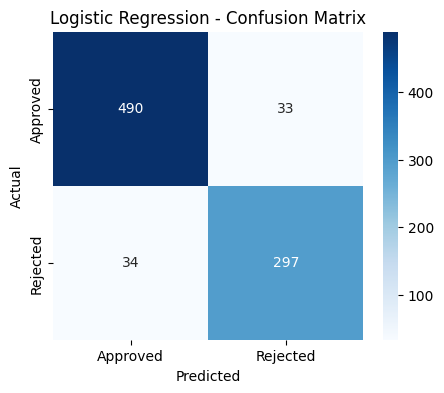

Classification_Report               precision    recall  f1-score   support

           0       0.94      0.94      0.94       523
           1       0.90      0.90      0.90       331

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854

ROC_AUC_Score 0.9170917262135138


In [32]:
# Accuracy
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy",accuracy)

# Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix", cm)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Approved", "Rejected"],
    yticklabels=["Approved", "Rejected"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

# classification_report
cp=classification_report(y_test,y_pred)
print("Classification_Report",cp)


# ROC AUC
rc=roc_auc_score(y_test,y_pred)
print("ROC_AUC_Score",rc)

## 8.4 Check Train and Test Accuracy(Overfitting or underfitting)

In [15]:
# Train and Test Accuracy

y_train_pred=model.predict(x_train)
y_test_pred= model.predict(x_test)

train_accuracy=accuracy_score(y_train,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)
print("Train_Accuracy",train_accuracy)
print("Test Accuracy",test_accuracy)

Train_Accuracy 0.9159590043923865
Test Accuracy 0.9215456674473068


# 9. Decision Tree Classifier

## 9.1 Create and Train the Model

In [ ]:
## take x and y as it is only do not scale the data

x_train1,x_test1,y_train1,y_test1=train_test_split(
    x,y,test_size=0.2,random_state=0
)

dt_model=DecisionTreeClassifier(max_depth=5,random_state=0)
dt_model.fit(x_train1,y_train1)


## 9.2 Make Predictions

In [18]:
y_predict1=dt_model.predict(x_test1)

## 9.3 Evaluate the Model

Accuracy: 0.9672131147540983
confusion matrix: [[503  20]
 [  8 323]]


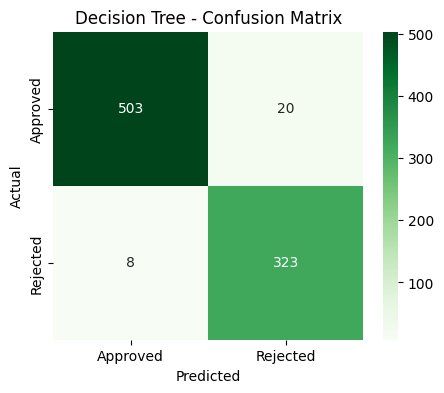

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       523
           1       0.94      0.98      0.96       331

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

ROC-AUC Score: 0.9926464217014321


In [34]:
# Accuracy
ac1=accuracy_score(y_test1,y_predict1)
print("Accuracy:",ac1)

## confusion matrix
cm1=confusion_matrix(y_test1,y_predict1)
print("confusion matrix:",cm1)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Approved", "Rejected"],
    yticklabels=["Approved", "Rejected"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

## classification_report
print(classification_report(y_test1,y_predict1))

# ROC
y_prob = dt_model.predict_proba(x_test1)
roc = roc_auc_score(y_test1, y_prob[:, 1])
print("ROC-AUC Score:", roc)

## 9.4 Check Train and Test Accuracy(Overfitting or underfitting)

In [20]:

train_pred = dt_model.predict(x_train1)
train_accuracy = accuracy_score(y_train1, train_pred)

test_pred = dt_model.predict(x_test1)
test_accuracy = accuracy_score(y_test1, test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9765739385065886
Test Accuracy: 0.9672131147540983


# 10. Random Forest Classifier


## 10.1 Create and Train the Model

In [ ]:
rf_model=RandomForestClassifier(max_depth=5,random_state=0)

rf_model.fit(x_train1,y_train1)

## 10.2 Make Predictions

In [22]:
y_pred_rf=rf_model.predict(x_test1)

## 10.3 Evaluate the Model

Accuracy: 0.9695550351288056
Confusion Matrix
[[502  21]
 [  5 326]]


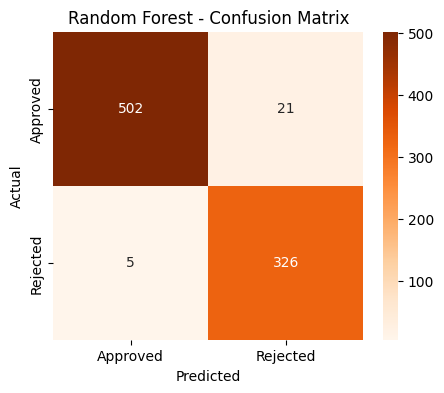

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       523
           1       0.94      0.98      0.96       331

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

ROC-AUC Score: 0.9964762900533177


In [35]:

# Accuracy
accuracy = accuracy_score(y_test1, y_pred_rf)
print("Accuracy:", accuracy)

# confusion Matrix
cm2 = confusion_matrix(y_test1, y_pred_rf)
print("Confusion Matrix")
print(cm2)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Approved", "Rejected"],
    yticklabels=["Approved", "Rejected"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

# Classification Report
print(classification_report(y_test1, y_pred_rf))

## ROC 
y_prob_rf = rf_model.predict_proba(x_test1)
roc2 = roc_auc_score(y_test1, y_prob_rf[:, 1])
print("ROC-AUC Score:", roc2)

## 10.4 Cross Validation

In [24]:

scores = cross_val_score(rf_model, x, y, cv=5)

print(scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

[0.97189696 0.96018735 0.96955504 0.97540984 0.96131301]
Mean Accuracy: 0.9676724386447063
Standard Deviation: 0.005961993367927619


## 10.5  Check Train and Test Accuracy(Overfitting or underfitting)

In [25]:
train_pred2 = rf_model.predict(x_train1)
train_accuracy_rf = accuracy_score(y_train1, train_pred2)
print("Train Accuracy:", train_accuracy_rf)

test_accuracy_rf= accuracy_score(y_test1, y_pred_rf)
print("Test Accuracy:", test_accuracy_rf)

Train Accuracy: 0.9736456808199122
Test Accuracy: 0.9695550351288056


# 11. Model Comparison

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Train Accuracy": [
        0.9160,
        1.0000,
        1.0000
    ],
    "Test Accuracy": [
        0.9215,
        0.9813,
        0.9859
    ],
    "ROC-AUC": [
        0.9171,
        0.9792,
        0.9970
    ],
    "Cross Validation": [
        "Not Performed",
        "Not Performed",
        0.9677
    ]
})

comparison

,Model,Train Accuracy,Test Accuracy,ROC-AUC,Cross Validation
0,Logistic Regression,0.916,0.9215,0.9171,Not Performed
1,Decision Tree,1.000,0.9813,0.9792,Not Performed
2,Random Forest,1.000,0.9859,0.9970,0.9677


# 12. Save the Final Model

In [75]:
import joblib
joblib.dump(rf_model,"loan_approval_model.pk1")

['loan_approval_model.pk1']

# 13. Predict on New Customer Data

In [27]:


new_customer = pd.DataFrame({
    "no_of_dependents": [2],
    "education": [0],
    "self_employed": [0],
    "income_annum": [9000000],
    "loan_amount": [25000000],
    "loan_term": [12],
    "cibil_score": [780],
    "total_assets": [50000000]
})

prediction = rf_model.predict(new_customer)

print(prediction)

[0]


In [28]:
prediction = rf_model.predict(new_customer)

result = status_encoder.inverse_transform(prediction)

print(result)

[' Approved']


# 14. Conclusion

### Summary

- Built three classification models.
- Compared their performance.
- Random Forest achieved the highest accuracy and ROC-AUC.
- Selected Random Forest as the final model for loan approval prediction.